# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdulwasay45/flyrankinternship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**Playbook goal**  
Produce a ranked review queue so an editor knows **which pages to look at first** and **why**.

**Actions the system can suggest**
| Action | When it appears | Meaning |
|--------|-----------------|---------|
| `refresh` | stale + still visible | Content is old and still getting impressions — review for update |
| `refresh_and_review_ctr` | visible + weak CTR for position | Page is seen but under-clicked — check title/meta/intent match |
| `expand_and_refresh` | thin + visible | Short page with real volume — consider adding missing depth |
| `monitor` | lower priority | Keep an eye on; not urgent this cycle |

**Reason codes (transparent tags)**
- `stale_visible_page` — days_since_last_update ≥ 180 and impressions ≥ 500  
- `low_ctr_visible_page` — impressions ≥ 500, position 1–20, CTR < 0.5  
- `declining_with_demand` — recent trend down and still has volume  
- `model_decline_risk` — model probability high (when model is used)  
- `general_refresh_review` — fallback

Every row in the queue carries: rank, score, primary reason code, suggested action, and a short human-readable note.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
import os, sys, subprocess, json
from pathlib import Path

# ---------- path setup ----------
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPO_URL = "https://github.com/abdulwasay45/flyrankinternship.git"
    REPO_DIR = "flyrankinternship"
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.exists("data/raw/content_refresh_anonymized.csv") and os.getcwd() != "/":
        os.chdir("..")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)
print(f"Loaded {len(df):,} pages")

# ---------- transparent score + reason + action ----------
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
low_ctr = (
    (df["impressions_90d"] >= 500) &
    (df["avg_position"] > 0) & (df["avg_position"] <= 20) &
    (df["ctr"] < 0.5)
).astype(int)
thin = (
    (df["word_count"].fillna(0) > 0) & (df["word_count"] < 1200) &
    (df["impressions_90d"] >= 250)
).astype(int)

df["playbook_score"] = (
    stale * visible * np.log1p(df["impressions_90d"])
    + low_ctr * np.log1p(df["impressions_90d"]) * 0.5
    + thin * np.log1p(df["impressions_90d"]) * 0.3
)

def primary_reason(row):
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "stale_visible_page"
    if (row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5):
        return "low_ctr_visible_page"
    if (row["word_count"] > 0 and row["word_count"] < 1200 and row["impressions_90d"] >= 250):
        return "thin_visible_page"
    if row["trend_direction"] == "down" and row["impressions_90d"] >= 100:
        return "declining_with_demand"
    return "general_refresh_review"

df["reason_code"] = df.apply(primary_reason, axis=1)

def action_from_reason(r):
    return {
        "stale_visible_page": "refresh",
        "low_ctr_visible_page": "refresh_and_review_ctr",
        "thin_visible_page": "expand_and_refresh",
        "declining_with_demand": "refresh",
        "general_refresh_review": "monitor",
    }.get(r, "monitor")

df["suggested_action"] = df["reason_code"].map(action_from_reason)
df["playbook_rank"] = df["playbook_score"].rank(method="first", ascending=False).astype(int)

queue = df.sort_values("playbook_rank").copy()
print("Top 10 of the action queue:")
print(queue[["playbook_rank", "suggested_action", "reason_code", "impressions_90d",
             "days_since_last_update", "avg_position", "ctr", "trend_direction"]].head(10).to_string(index=False))

Loaded 30,000 pages
Top 10 of the action queue:
 playbook_rank suggested_action        reason_code  impressions_90d  days_since_last_update  avg_position  ctr trend_direction
             1          refresh stale_visible_page            61678                     194          19.7 0.15            down
             2          refresh stale_visible_page            13299                     193          10.5 0.49            down
             3          refresh stale_visible_page             7558                     193          17.9 0.20            down
             4          refresh stale_visible_page             4556                     194          16.4 0.33            down
             5          refresh stale_visible_page             1697                     193          15.8 0.12            down
             6          refresh stale_visible_page            59472                     194          24.8 0.13            down
             7          refresh stale_visible_page             

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use**
- Audience: content editor / SEO specialist who has limited review capacity each week.
- Job: open the ranked queue, start at rank 1, read the reason code, decide refresh / rewrite / monitor / skip.
- Output is **decision-support**, not an automated order.

**Where the playbook is valid**
- On portfolios that look like the training data (similar content types, impression ranges, freshness patterns).
- Under the same feature definitions and volume floors used to build the score.
- When the editor still applies human judgment on brand, legal, and seasonal context the model cannot see.

**Where it stops being valid**
- Brand-new content types or markets never seen in training.
- Pages whose traffic is dominated by news, seasonality, or one-off events the features do not capture.
- Any claim that “refreshing this page will increase traffic” — we have no causal design, only ranking associations.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**What a person must check before acting**
1. Is this page intentionally evergreen / legal / compliance content that should stay static?
2. Was a refresh or title test already done in the last 60 days?
3. Does the reason code match what the editor sees on the live page (title, intent, competition)?
4. Is volume high enough that a change is worth the editor’s time?
5. Are there brand or legal constraints the data cannot know?

**What should NEVER be automated**
- Publishing a rewritten page without human review.
- Changing titles/meta at scale without a human-approved template or test plan.
- Deleting or noindexing pages solely because the score is low.
- Treating the model score as a performance review of an author or team.
- Acting on pages with extremely low volume where noise dominates signal.

**Cost / value thinking**
- Cost of a false positive (high rank, not worth refreshing): wasted editor hours.
- Cost of a false negative (missed declining page): continued traffic loss that might have been recoverable.
- Capacity: if the team can only review ~20–50 pages per cycle, Precision@20 / Precision@50 is the metric that matches the real decision.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Signals that the recommendations may have gone stale**
- Precision@50 of the current queue (measured against a later observed decline label) falls below the baseline rule for two consecutive evaluation cycles.
- The mix of reason codes shifts sharply (e.g. almost everything becomes `monitor`) without a clear portfolio change.
- A new content type or client segment appears that was never in training.
- Feature distributions drift (median impressions, age, CTR) outside the ranges seen at training time.

**Practical retrain / refresh triggers**
- Re-score the queue at least monthly (or after any major site migration).
- Re-train the model when client-holdout Precision@50 drops materially vs the frozen baseline, or when new months of warehouse data become available.
- Keep the transparent rule baseline frozen so every new model has an honest bar to beat.

**Light monitoring checklist (for the paper and for ops)**
- [ ] Queue regenerated on a known schedule  
- [ ] Base rate and Precision@K logged each run  
- [ ] Reason-code distribution compared to previous run  
- [ ] Human override rate tracked (how often editors reject the top suggestions)

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The files below are what the research paper will build on next week.  
The queue CSV stays out of git (CI blocks data files); the notebook regenerates it.  
Metrics JSON and any figures are safe to commit as receipts.

Wrote work/outputs/action_playbook_queue.csv
Rows: 30,000 | Top-50 declining rate: 0.700
Wrote work/outputs/w07_playbook_metrics.json
{
  "n_pages": 30000,
  "base_rate_declining": 0.5420666666666667,
  "top20_declining_rate": 0.9,
  "top50_declining_rate": 0.7,
  "action_counts": {
    "monitor": 13173,
    "refresh_and_review_ctr": 9749,
    "refresh": 7014,
    "expand_and_refresh": 64
  },
  "reason_counts": {
    "general_refresh_review": 13173,
    "low_ctr_visible_page": 9749,
    "declining_with_demand": 6997,
    "thin_visible_page": 64,
    "stale_visible_page": 17
  }
}


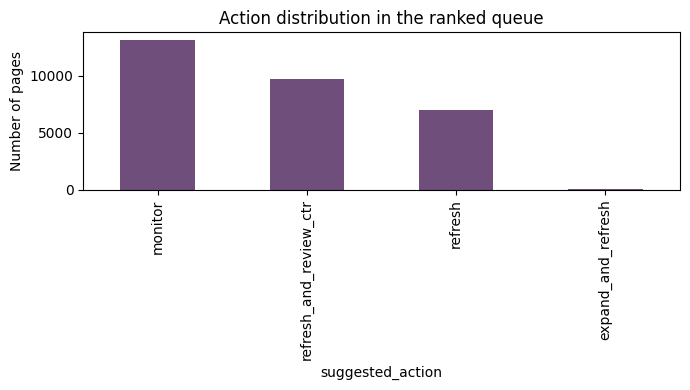

Wrote work/figures/action_distribution.png

Playbook exports ready for the research paper.


In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ---------- final queue export ----------
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

out_cols = [
    "content_id", "client_id", "playbook_rank", "playbook_score",
    "reason_code", "suggested_action", "is_declining_label",
    "impressions_90d", "days_since_last_update", "avg_position", "ctr",
    "word_count", "trend_direction", "content_type", "position_tier",
]
queue[out_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Wrote work/outputs/action_playbook_queue.csv")
print(f"Rows: {len(queue):,} | Top-50 declining rate: {queue.head(50)['is_declining_label'].mean():.3f}")

# ---------- summary metrics (safe to commit) ----------
summary = {
    "n_pages": int(len(queue)),
    "base_rate_declining": float(queue["is_declining_label"].mean()),
    "top20_declining_rate": float(queue.head(20)["is_declining_label"].mean()),
    "top50_declining_rate": float(queue.head(50)["is_declining_label"].mean()),
    "action_counts": queue["suggested_action"].value_counts().to_dict(),
    "reason_counts": queue["reason_code"].value_counts().to_dict(),
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Wrote work/outputs/w07_playbook_metrics.json")
print(json.dumps(summary, indent=2))

# ---------- simple action-distribution figure (optional, for the paper) ----------
try:
    import matplotlib.pyplot as plt
    ax = queue["suggested_action"].value_counts().plot(kind="bar", color="#6F4E7C", figsize=(7, 4))
    ax.set_title("Action distribution in the ranked queue")
    ax.set_ylabel("Number of pages")
    plt.tight_layout()
    plt.savefig("work/figures/action_distribution.png", dpi=120)
    plt.show()
    print("Wrote work/figures/action_distribution.png")
except Exception as e:
    print("Figure skipped:", e)

print("\nPlaybook exports ready for the research paper.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.